In [1]:
import os 
# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/tabula_muris_brain/Leaflet


In [2]:
import sys
sys.path.append('../../utils')
from functions import * 

In [3]:
from importlib import reload
import sys

# Path to the Leaflet repository
PATH_TO_LEAFLET_REPO = '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/'
sys.path.append(PATH_TO_LEAFLET_REPO)

In [4]:
import cell_state_asign_consistency
reload  (cell_state_asign_consistency)

<module 'cell_state_asign_consistency' from '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/cell_state_asign_consistency.py'>

In [5]:
import betabinomo_mix_singlecells
reload (betabinomo_mix_singlecells)

<module 'betabinomo_mix_singlecells' from '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/betabinomo_mix_singlecells.py'>

In [6]:
from importlib import reload
from load_cluster_data import load_cluster_data
from betabinomo_mix_singlecells import *
#reload(betabinomo_mix_singlecells)
from cell_state_asign_consistency import *
#reload(cell_state_asign_consistency)
import torch
import sklearn.manifold 
import plotnine as p9
import time
# indicate plot should be small 4 by 4
import plotnine as p9
from plotnine import ggplot, geom_point, aes, stat_smooth, facet_wrap, geom_violin, theme, element_blank, geom_text
import plotnine
from tqdm import tqdm
plotnine.options.figure_size = (4, 4)
import seaborn as sns
sns.set_theme(style="whitegrid")

/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/statsmodels/compat/pandas.py:65: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.


### Settings and Load data

In [7]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

K = 50 # set to very high number 

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

hypers = {
    "eta" : 1./K, 
    "alpha_prior" : 1., # karin had 0.65 
    "pi_prior" : 1.
}

cpu


In [8]:
hypers["eta"]

0.02

### load_cluster_data takes ~ 5 minutes for ss2 brain data.... 

In [9]:
# this folder contains input data for each tissue cell type sample
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/Brain/train/'

final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data(
    input_folder = input_files_folder) 

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/Brain/train/
Finished reading in data from folder ...
['Brain_Non-Myeloid_brain_pericyte' 'Brain_Myeloid_microglial_cell'
 'Brain_Non-Myeloid_oligodendrocyte'
 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell'
 'Brain_Non-Myeloid_astrocyte' 'Brain_Non-Myeloid_endothelial_cell'
 'Brain_Non-Myeloid_neuron' 'Brain_Non-Myeloid_Bergmann_glial_cell'
 'Brain_Myeloid_macrophage']
5499
78813
The number of junctions in the data is:  78814
The number of cells in the data is:  5499
The number of cell types in the data is:  9


In [10]:
# ensure that in coo_counts_sparse.shape = (n_cells, n_genes) , n_cells is the same number as cell_ids_conversion.shape = (n_cells, num_variables)
assert coo_counts_sparse.shape[0] == cell_ids_conversion.shape[0]

In [11]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

The number of cells going into training data is:
5499
5499


/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/betabinomo_mix_singlecells.py:317: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)


In [12]:
print(K)

50


In [13]:
# set random seed
torch.manual_seed(0)

num_trials = 3 # should also be an argument that gets fed in
num_iters = 100 # should also be an argument that gets fed in

#K = 10

# loop over the number of trials (for now just testing using one trial but in general need to evaluate how performance is affected by number of trials)
#reload(betabinomo_mix_singlecells)

start_time = time.time()

# Running for just one K and assessing similarity across trials 

results = [ calculate_CAVI(K, my_data, float_type, hypers, init_labels = None, num_iterations = num_iters) 
           for t in range(num_trials) ]


# write the above line use fstring
print(f"This took {time.time() - start_time} seconds")

Initialize VI params
Initializing variational parameters with N = 5499 cells and J = 78814 junctions
Got the initial ELBO ^
ELBO converged @ -4118573568.0  CAVI iteration #  16  complete
Initialize VI params
Initializing variational parameters with N = 5499 cells and J = 78814 junctions
Got the initial ELBO ^
ELBO converged @ -4118196992.0  CAVI iteration #  14  complete
Initialize VI params
Initializing variational parameters with N = 5499 cells and J = 78814 junctions
Got the initial ELBO ^
ELBO converged @ -4117022464.0  CAVI iteration #  15  complete
This took 129.02740812301636 seconds


### Evaluate the learned posteriors

In [14]:
running_multiple_K = False 
if running_multiple_K:
    elbos_ks = []
    for i in range(len(all_results_k)):
        print("Reporting ELBO for k = " + str(i+1))
        results = all_results_k[i]
        best = np.argmax([ g[-1][-1] for g in results ]) # best ELBO within trial
        ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[best]
        elbos_all = np.array(elbos_all)
        print("ELBO: " + str(elbos_all[-1]))
        elbos_ks.append(elbos_all[-1])
    
    elbos_ks = pd.DataFrame(elbos_ks)
    elbos_ks["k"] = range(K)
    best_k = elbos_ks.sort_values(by=0, ascending=False).head(1)
    results = all_results_k[best_k.index[0]]
    print("The k with the highest ELBO is: " + str(best_k.index[0]+1))
    K = best_k.index[0]+1 
    print(K)

In [15]:
len(results)

3

### Evaluate how consistent the cell type assignments are across the trials of the mixture model

The trial with the highest ELBO was 2


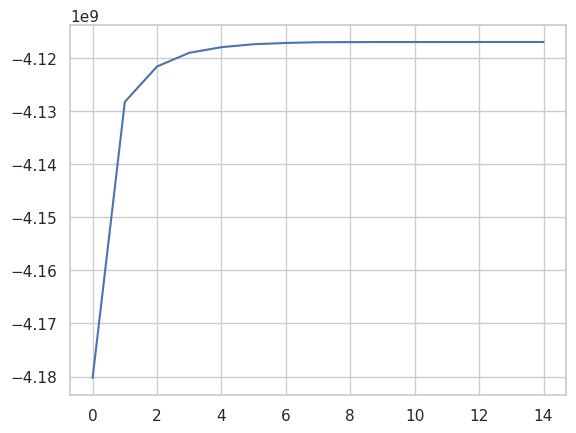

In [16]:
best = np.argmax([ g[-1][-1] for g in results ]) # final ELBO
print(f"The trial with the highest ELBO was {best}")
ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[best]
elbos_all = np.array(elbos_all)
plt.plot(elbos_all[1:]); plt.show()

In [ ]:
juncs_probs = ALPHA_f / (ALPHA_f+PI_f)   
 
plt.hist(juncs_probs.cpu().numpy().flatten(), 20)
plt.title('Histogram of learned junction probabilities') 
plt.xlabel('Probability of junction success')
plt.show()

In [ ]:
PHI_f_plot = pd.DataFrame(PHI_f.cpu().numpy())
PHI_f_plot['cell_id'] = cell_ids_conversion["cell_type"].to_numpy()
PHI_f_summ = PHI_f_plot.groupby('cell_id').mean()
print(PHI_f_summ)

In [ ]:
# How much each cell state is used 
#latent proportions describe the general prevalence of each cluster in the datasetN
# cluster proportions via theta ~ dirichlet(GAMMA_f)
# each cell gets an assignment to a cluster via z_c | theta ~ categorical(theta)

theta = GAMMA_f / GAMMA_f.sum()
theta = theta.cpu().numpy()
theta_sorted = np.sort(theta)
theta_sorted

In [ ]:
PHI_f.shape #<- this is the matrix of probabilities of each cell belonging to each cluster

In [ ]:
theta_sorted

In [ ]:
x = PHI_f.cpu().numpy()
_ = plt.hist(x.flatten(),100)

In [ ]:
juncs_probs_df = pd.DataFrame(juncs_probs, columns = range(K))
# add "cell_state" to each column name 
juncs_probs_df.columns = ["cell_state_" + str(col) for col in juncs_probs_df.columns]
juncs_probs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values
# convert to juncs_probs to pandas dataframe and calculate mean and std across cell states/topics
juncs_probs_df["junction_id"] = junction_ids_conversion.junction_id.values

In [ ]:
def plot_juncObsUsage(junc_index):

    # print junction ID using junction_ids_conversion
    print(junction_ids_conversion[junction_ids_conversion["junction_id_index"] == junc_index])
    junc_id = junction_ids_conversion[junction_ids_conversion["junction_id_index"] == junc_index].junction_id.values[0]

    # get data for just junc_index 
    junc_dat=final_data[final_data.junction_id_index==junc_index]
    print(junc_dat.cell_type.value_counts())

    # make violin plot for junc_dat junction usage ratio coloured by cell_type and rotate plot 90 degrees
    plot = ggplot(junc_dat, aes(x='cell_type', y='juncratio', fill="cell_type")) + geom_violin() + geom_point() + plotnine.labels.ggtitle(junc_id) + plotnine.coords.coord_flip() 

    # add number of cells in each cell_type to plot 
    print(plot)

def plot_juncProbs(junc_index):
    
    # print junction ID using junction_ids_conversion
    print(junction_ids_conversion[junction_ids_conversion["junction_id_index"] == junc_index])
    junc_id = junction_ids_conversion[junction_ids_conversion["junction_id_index"] == junc_index].junction_id.values[0]
    
    # get data for just junc_index 
    junc_dat=juncs_probs_df[juncs_probs_df.junction_id_index==junc_index]
    junc_dat = junc_dat.melt().iloc[0:K]
    junc_dat.value = junc_dat.value.astype(float)
    # make violin plot for junc_dat junction usage ratio coloured by cell_type
    # don't print x-axis tick labels 
    plot = ggplot(junc_dat, aes(x='variable', y='value')) + geom_point() + theme(axis_text_x=element_blank())
    print(plot)

In [ ]:
# calculate sd deviation for each junction for cell states 0 to 19 
juncs_probs_df["sd"] = juncs_probs_df.iloc[:,0:K].std(axis=1)

In [ ]:
# convert PHI_f to a dataframe and add a column with cell ID and cell type 
PHI_f = pd.DataFrame(PHI_f)

# Add "CellState" to each column 
PHI_f.columns = ["CellState_" + str(i) for i in range(PHI_f.shape[1])]
PHI_f['cell_id'] = cell_ids_conversion.cell_id.values
PHI_f['cell_type'] = cell_ids_conversion.cell_type.values

In [ ]:
PHI_f.groupby('cell_type').sum()

In [ ]:
# get likelihood ratio/bayes factor score for ALL junctions 
# let's compare just state X and Y

scores_all_juncs = []
for junc_index in range(juncs_probs.shape[0]):
    a = ALPHA_f[junc_index, [3,6]]
    b = PI_f[junc_index, [3,6]]
    scores_all_juncs.append(score(a, b).item())

# turn scores_all_juncs into dataframe and add junction_id_index as a column
scores_all_juncs_df = pd.DataFrame(scores_all_juncs, columns = ["score"])
scores_all_juncs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values
scores_all_juncs_df.sort_values(by="score", ascending=False).head(10)
juncs_test=scores_all_juncs_df.sort_values(by="score", ascending=False).head(2).junction_id_index.values

In [ ]:
# for each junction in top10juncs_state1, run plot_juncObsUsage and plot_juncProbs
for junc in juncs_test:
    plot_juncObsUsage(junc)
    plot_juncProbs(junc)

In [ ]:
# save cell assignments to file for downstream analysis
output_dir = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/'

# BBmixture model cell assignments
output_file = os.path.join(output_dir, 'Leaflet_BBmixture.csv')
PHI_f.to_csv(output_file, index=True, header=True)
print('Saved Leaflet latent cell states to {}'.format(output_file))

In [ ]:
# Create a 2 columns x 5 rows grid for the subplots
fig, axes = plt.subplots(5, 4, figsize=(12, 25))
# Flatten the axes array to loop through each subplot
axes = axes.flatten()

# plot distribution of values in each CellState_X column for each cell type
for i in range(K):
    dat = PHI_f[['CellState_{}'.format(i), "cell_type"]]
    dat = dat.copy()
    dat["CellState"] = dat["CellState_{}".format(i)]
    sns.violinplot(x='cell_type', y='CellState', data=dat, ax=axes[i], scale='count')
    # reduce size of x-axis labels font
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90, fontsize=6)
    axes[i].set_title('CellState_{}'.format(i))

# Remove any empty subplots (if K is less than 10)
for j in range(K, 20):
    fig.delaxes(axes[j])

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In [ ]:
# group by cell_type and sum across each cellstate 
PHI_f.groupby('cell_type').sum()

In [ ]:
sum_prop=PHI_f.groupby('cell_type').sum()/PHI_f.groupby('cell_type').count()
# remove cell_id column 
sum_prop=sum_prop.drop(columns=['cell_id'])

In [ ]:
PHI_f.groupby('cell_type').sum()

In [ ]:
PHI_f.groupby('cell_type').count()

In [ ]:
#masked_data = np.ma.masked_equal(sum_prop, 0)
sns.set(font_scale=0.8)  # Adjust font size for labels
# make figure bigger 
plt.figure(figsize=(10, 8))
# make font size of xtickts and yticks bigger
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
sns.heatmap(sum_prop, annot=True, fmt=".2f", cmap='viridis')

In [ ]:
sum_prop

In [ ]:
sum_prop.index

In [ ]:
# now let's give the cell states new labels based on what cell types they are associated with 
# go through sum_prop and for each cell state find the cell type with the highest proportion
# assign that cell type to the cell state
cell_type_labels = {}
for state in sum_prop.columns:
    max_prop = 0
    max_celltype = ''
    for celltype in sum_prop.index:
        if sum_prop.loc[celltype, state] > max_prop:
            max_prop = sum_prop.loc[celltype, state]
            max_celltype = celltype
    cell_type_labels[state] = max_celltype, round(max_prop, 3)
print(cell_type_labels)

In [ ]:
cell_type_labels

In [ ]:
# Let's find the junctions that are the most differentially spliced between microglia and astrocytes 
scores_all_juncs = []
cellstate1 = 0
cellstate2 = 1

for junc_index in range(juncs_probs.shape[0]):
    a = ALPHA_f[junc_index, [cellstate1,cellstate2]]
    b = PI_f[junc_index, [cellstate1,cellstate2]]
    scores_all_juncs.append(score(a, b).item())

# turn scores_all_juncs into dataframe and add junction_id_index as a column
scores_all_juncs_df = pd.DataFrame(scores_all_juncs, columns = ["score"])
scores_all_juncs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values
scores_all_juncs_df.sort_values(by="score", ascending=False).head(10)
juncs_test=scores_all_juncs_df.sort_values(by="score", ascending=False).head(2).junction_id_index.values

In [ ]:
scores_all_juncs
juncs_test

In [ ]:
for junc in juncs_test:
    plot_juncObsUsage(junc)
    plot_juncProbs(junc)

In [ ]:
# get one matrix CxC just summing up across all trials and so the higher the number the higher confidence that theya re asigned together 

In [ ]:
ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[best]

In [ ]:
# Evaluate predictive log likelihood score on validation data
# Use the learned posteriors to see how well the model fits the data
theta

In [ ]:
juncs_probs

In [ ]:
clusts = PHI_f
clusts

In [ ]:
# validation data 
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/Brain/validation/'

val_data, val_coo_counts_sparse, val_coo_cluster_sparse, val_cell_ids_conversion, val_junction_ids_conversion = load_cluster_data(
    input_folder = input_files_folder) 
cell_index_tensor_val, junc_index_tensor_val, my_data_val = make_torch_data(val_data, **float_type)

In [ ]:
import betabinomo_mix_singlecells
reload(betabinomo_mix_singlecells)

In [ ]:
# set random seed
torch.manual_seed(0)

num_trials = 1 # should also be an argument that gets fed in
num_iters = 40 # should also be an argument that gets fed in
K = 12

# loop over the number of trials (for now just testing using one trial but in general need to evaluate how performance is affected by number of trials)
#reload(betabinomo_mix_singlecells)

start_time = time.time()
all_results_k = []
all_ll_k = []

for k in range(K):
    k = k + 1
    print(f"Running with {k} cell states")
    results = [ betabinomo_mix_singlecells.calculate_CAVI(k, my_data, float_type, hypers, init_labels = None, num_iterations = num_iters) 
           for t in range(num_trials) ]
    
    all_results_k.append(results)
    ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[0]
    juncs_probs = ALPHA_f / (ALPHA_f+PI_f)   
    juncs_probs_df = pd.DataFrame(juncs_probs.numpy())
    # rename columns to be "state_0", "state_1", etc.
    juncs_probs_df.columns = ["state_" + str(i) for i in range(juncs_probs_df.shape[1])]
    juncs_probs_df["junction_id_index"] = juncs_probs_df.index

    # merge with val_data 
    val_data_run = val_data.merge(juncs_probs_df, on="junction_id_index")
    theta = GAMMA_f / GAMMA_f.sum()
    theta = theta.cpu().numpy()

    # evaluate predictive log likelihood on validation set 
    print("Calculating predictive log likelihood on validation set")
    ll = betabinomo_mix_singlecells.calculate_predictive_lik(theta, val_data_run)
    all_ll_k.append(ll)
    print(f"Predictive log likelihood on validation set is {ll}")

# write the above line use fstring
print(f"This took {time.time() - start_time} seconds")

In [ ]:
(all_ll_k == np.max(all_ll_k))

In [ ]:
all_ks = pd.DataFrame(np.array(all_ll_k))
all_ks["k"] = all_ks.index
all_ks.columns = ["ll", "k"]
all_ks.sort_values("ll", ascending=False)

In [ ]:
import matplotlib.pyplot as plt

# Given data
data = [
    (10, -3.759537e+07),
    (11, -3.792445e+07),
    (9, -3.812037e+07),
    (7, -3.837194e+07),
    (8, -3.856408e+07),
    (6, -3.934490e+07),
    (5, -3.983091e+07),
    (4, -4.040786e+07),
    (2, -4.199341e+07),
    (3, -4.218076e+07),
    (1, -4.448278e+07),
    (0, -4.958535e+07)
]

# Unpack data into separate lists for x and y values
x_values, y_values = zip(*data)

# Create a bar plot
plt.bar(x_values, y_values, color='blue')

# Add labels and title
plt.xlabel('k', fontsize=14)
plt.ylabel('Log Likelihood (ll)', fontsize=14)
plt.title('Log Likelihood vs k', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Show the plot
plt.show()
